In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.features.feature_engine import FeatureEngine
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive
from src.models.ngboost_model import predict_mean
from src.pipeline.pipeline_pts import build_ngboost_points_features

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

us_file = get_latest_file(f'NBA_US_{today}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{today}*.csv')

if us_file is None:
    raise FileNotFoundError(f"No NBA_US file found for {today}")
if dfs_file is None:
    raise FileNotFoundError(f"No NBA_DFS file found for {today}")

s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
usData = pd.read_csv(us_file)
dfsData = pd.read_csv(dfs_file)

print(f"Loaded: {us_file.name}")
print(f"Loaded: {dfs_file.name}")
dfsData.head()

Loaded: NBA_US_20251213_110508.csv
Loaded: NBA_DFS_20251213_110106.csv


,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,PrizePicks,player_points,Jalen Brunson,Over,29.5,-137,2025-12-13,2025-12-13T19:00:00Z,2025-12-13 11:01:06
1,PrizePicks,player_points,Jalen Brunson,Under,29.5,-137,2025-12-13,2025-12-13T19:00:00Z,2025-12-13 11:01:06
2,PrizePicks,player_points,Paolo Banchero,Over,22.5,-137,2025-12-13,2025-12-13T19:00:00Z,2025-12-13 11:01:06
3,PrizePicks,player_points,Paolo Banchero,Under,22.5,-137,2025-12-13,2025-12-13T19:00:00Z,2025-12-13 11:01:06
4,PrizePicks,player_points,Karl-Anthony Towns,Over,21.5,-137,2025-12-13,2025-12-13T19:00:00Z,2025-12-13 11:01:06


In [3]:
# dfsData = pd.read_csv('data/raw/player_lines/NBA_DFS_20251206_134221.csv')
# usData = pd.read_csv('data/raw/player_lines/NBA_US_20251206_134342.csv')
# s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')

In [3]:
name = 'Shai Gilgeous-Alexander'
betting_line = 31.5 
odds = -137

engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "fg3a_model": "src/models/saved/fg3a_model.pkl",
    "fta_model": "src/models/saved/fta_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

# Get prediction
result = engine.project_player(
    player_name=name,
    data=s26,
    date=current_date,
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)

print("Prediction Result:")
print(f"  Predicted Minutes: {result['predicted_minutes']:.2f}")
print(f"  Predicted FGA: {result['predicted_fga']:.2f}")
print(f"  Predicted FG3A: {result['predicted_fg3a']:.2f}")
print(f"  Predicted FTA: {result['predicted_fta']:.2f}")
print(f"  Predicted Points: {result['predicted_points']:.2f}")

player_df = s26[s26['PLAYER_NAME'] == name]
print(f"{name} has played {len(player_df)} games this season and has a line set at {betting_line} for today's game.")
print(f"    In the last 5 games, he has been on the court for {round(player_df['MIN'].tail(5).sum(),2)} minutes, averaging {player_df['MIN'].tail(5).mean():.2f} minutes per game")
print(f"    In the last 5 games, he has attempted {player_df['FGA'].tail(5).sum()} field goals, averaging {player_df['FGA'].tail(5).mean():.2f} field goals per game")
print(f"    In the last 5 games, he has attempted {player_df['FG3A'].tail(5).sum()} 3-point field goals, averaging {player_df['FG3A'].tail(5).mean():.2f} 3-point field goals per game")
print(f"    In the last 5 games, he has attempted {player_df['FTA'].tail(5).sum()} free throws, averaging {player_df['FTA'].tail(5).mean():.2f} free throws per game")
print(f"    In the last 5 games, he has scored {player_df['PTS'].tail(5).sum()} points, averaging {player_df['PTS'].tail(5).mean():.2f} points per game")
print(f"Average Opponent Defense Rating: {player_df['OPP_DEF_RATING'].tail(5).mean():.2f}")
print(f"{name} career high in points is {player_df['PTS'].max()}, and career low is {player_df['PTS'].min()}")

Prediction Result:
  Predicted Minutes: 32.35
  Predicted FGA: 15.94
  Predicted FG3A: 4.12
  Predicted FTA: 7.66
  Predicted Points: 23.88
Shai Gilgeous-Alexander has played 24 games this season and has a line set at 31.5 for today's game.
    In the last 5 games, he has been on the court for 162.49 minutes, averaging 32.50 minutes per game
    In the last 5 games, he has attempted 83 field goals, averaging 16.60 field goals per game
    In the last 5 games, he has attempted 20 3-point field goals, averaging 4.00 3-point field goals per game
    In the last 5 games, he has attempted 54 free throws, averaging 10.80 free throws per game
    In the last 5 games, he has scored 162 points, averaging 32.40 points per game
Average Opponent Defense Rating: 122.86
Shai Gilgeous-Alexander career high in points is 55, and career low is 23


In [22]:
# Create log-normal distribution using calibrations
if engine.ngboost_model_wrapper:
    # Get the model and features
    mean_model = engine.ngboost_model_wrapper['mean_model']
    features_list = engine.ngboost_model_wrapper['features']
    variance_calibration = engine.ngboost_model_wrapper.get('variance_calibration')
    bins = engine.ngboost_model_wrapper.get('bins')
    
    median_pred = result['predicted_points']
    
    feature_dict = build_ngboost_points_features(
        player_name=name,
        data=s26,
        current_date=current_date,
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp,
        predicted_minutes=result['predicted_minutes'],
        predicted_fga=result['predicted_fga'],
        predicted_fg3a=result.get('predicted_fg3a'),
        predicted_fta=result.get('predicted_fta')
    )
    
    if feature_dict:
        feature_vector = [feature_dict.get(f, 0.0) for f in features_list]
        feature_df = pd.DataFrame([feature_vector], columns=features_list)
        feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
        
        # Get distribution parameters
        dist = mean_model.pred_dist(feature_df[features_list].fillna(feature_df[features_list].median()))
        mean_log = float(dist.loc[0])
        scale_log = float(dist.scale[0])
        var_log = scale_log ** 2
        
        # Apply calibrations based on bins
        if variance_calibration and bins:
            low_bin, medium_bin, high_bin = bins[0], bins[1], bins[2]
            if (median_pred >= low_bin[0]) and (median_pred < low_bin[1]):
                var_log *= variance_calibration.get('low', 1.0)
                print(f"\nUsing LOW bin calibration: {variance_calibration.get('low')}")
            elif (median_pred >= medium_bin[0]) and (median_pred < medium_bin[1]):
                var_log *= variance_calibration.get('medium', 1.0)
                print(f"\nUsing MEDIUM bin calibration: {variance_calibration.get('medium')}")
            elif (median_pred >= high_bin[0]) and (median_pred < high_bin[1]):
                var_log *= variance_calibration.get('high', 1.0)
                print(f"\nUsing HIGH bin calibration: {variance_calibration.get('high')}")
        
        std_log = np.sqrt(var_log)
        distribution = lognorm(s=std_log, scale=np.exp(mean_log))
        
        print(f"\nLog-Normal Distribution Parameters:")
        print(f"  Mean (log space): {mean_log:.4f}")
        print(f"  Std (log space): {std_log:.4f}")
        print(f"  Median: {median_pred:.2f}")
        print(f"  Mean: {distribution.mean():.2f}")
        print(f"  Std: {distribution.std():.2f}")
        
        samples = distribution.rvs(size=10000)
        print(f"\nDistribution Statistics (from samples):")
        print(f"  5th percentile: {np.percentile(samples, 5):.2f}")
        print(f"  25th percentile: {np.percentile(samples, 25):.2f}")
        print(f"  50th percentile (median): {np.percentile(samples, 50):.2f}")
        print(f"  75th percentile: {np.percentile(samples, 75):.2f}")
        print(f"  95th percentile: {np.percentile(samples, 95):.2f}")
        
        # Monte Carlo Simulation
        print("\n" + "="*60)
        print("MONTE CARLO SIMULATION")
        print("="*60)
        
        # Create test lines in 0.5 intervals around betting line
        betting_line_rounded = round(betting_line * 2) / 2
        num_lines_below = 2  # 4 * 0.5 = 2.0 points below
        num_lines_above = 2  # 4 * 0.5 = 2.0 points above
        
        test_lines = []
        for i in range(-num_lines_below, num_lines_above + 1):
            test_line = betting_line_rounded + (i * 0.5)
            if test_line > 0:
                test_lines.append(test_line)
        
        # Ensure actual betting line is included
        if betting_line not in test_lines:
            test_lines.append(betting_line)
        
        test_lines = sorted(set(test_lines))
        
        # Convert odds to decimal
        if odds > 0:
            dec_odds = 1 + (odds / 100.0)
        else:
            dec_odds = 1 + (100.0 / abs(odds))
        
        print(f"\nTesting {len(samples):,} simulations against different lines:")
        print(f"Predicted Median: {median_pred:.2f} points")
        print(f"Betting Line: {betting_line:.1f} points | Odds: {odds:+d} ({dec_odds:.3f} decimal)")
        print(f"Test Lines: {[f'{l:.1f}' for l in test_lines]}\n")
        
        results = []
        for test_line in test_lines:
            # Calculate probabilities - these should sum to 100%
            prob_over = 1 - distribution.cdf(test_line)
            prob_under = distribution.cdf(test_line)
            
            # Monte Carlo: count wins (for validation)
            over_wins = np.sum(samples > test_line)
            under_wins = np.sum(samples <= test_line)
            over_rate = over_wins / len(samples)
            under_rate = under_wins / len(samples)
            
            # Calculate expected value using actual odds
            ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
            ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)
            
            results.append({
                'Line': test_line,
                'Prob_Over': prob_over,
                'Prob_Under': prob_under,
                'MC_Over_Rate': over_rate,
                'MC_Under_Rate': under_rate,
                'EV_Over': ev_over,
                'EV_Under': ev_under
            })
            
            # Determine best bet
            if ev_over > ev_under and ev_over > 0:
                best_bet = f"OVER {test_line:.1f} (EV: {ev_over:+.3f})"
            elif ev_under > ev_over and ev_under > 0:
                best_bet = f"UNDER {test_line:.1f} (EV: {ev_under:+.3f})"
            else:
                best_bet = "No positive EV"
            
            # Highlight the actual betting line
            line_marker = " <-- BETTING LINE" if abs(test_line - betting_line) < 0.01 else ""
            print(f"Line: {test_line:.1f}{line_marker}")
            print(f"  Over: {prob_over:.1%} (MC: {over_rate:.1%}) | EV: {ev_over:+.3f}")
            print(f"  Under: {prob_under:.1%} (MC: {under_rate:.1%}) | EV: {ev_under:+.3f}")
            print(f"  Sum: {(prob_over + prob_under):.1%}")  # Should be 100%
            print(f"  → {best_bet}\n")


Using HIGH bin calibration: 0.94

Log-Normal Distribution Parameters:
  Mean (log space): 2.9244
  Std (log space): 0.2438
  Median: 17.62
  Mean: 19.18
  Std: 4.75

Distribution Statistics (from samples):
  5th percentile: 12.57
  25th percentile: 15.77
  50th percentile (median): 18.64
  75th percentile: 22.00
  95th percentile: 27.99

MONTE CARLO SIMULATION

Testing 10,000 simulations against different lines:
Predicted Median: 17.62 points
Betting Line: 29.5 points | Odds: -137 (1.730 decimal)
Test Lines: ['28.5', '29.0', '29.5', '30.0', '30.5']

Line: 28.5
  Over: 4.0% (MC: 4.3%) | EV: -0.930
  Under: 96.0% (MC: 95.7%) | EV: +0.660
  Sum: 100.0%
  → UNDER 28.5 (EV: +0.660)

Line: 29.0
  Over: 3.5% (MC: 3.6%) | EV: -0.940
  Under: 96.5% (MC: 96.4%) | EV: +0.670
  Sum: 100.0%
  → UNDER 29.0 (EV: +0.670)

Line: 29.5 <-- BETTING LINE
  Over: 3.0% (MC: 3.0%) | EV: -0.949
  Under: 97.0% (MC: 97.0%) | EV: +0.679
  Sum: 100.0%
  → UNDER 29.5 (EV: +0.679)

Line: 30.0
  Over: 2.5% (MC: 2.6%

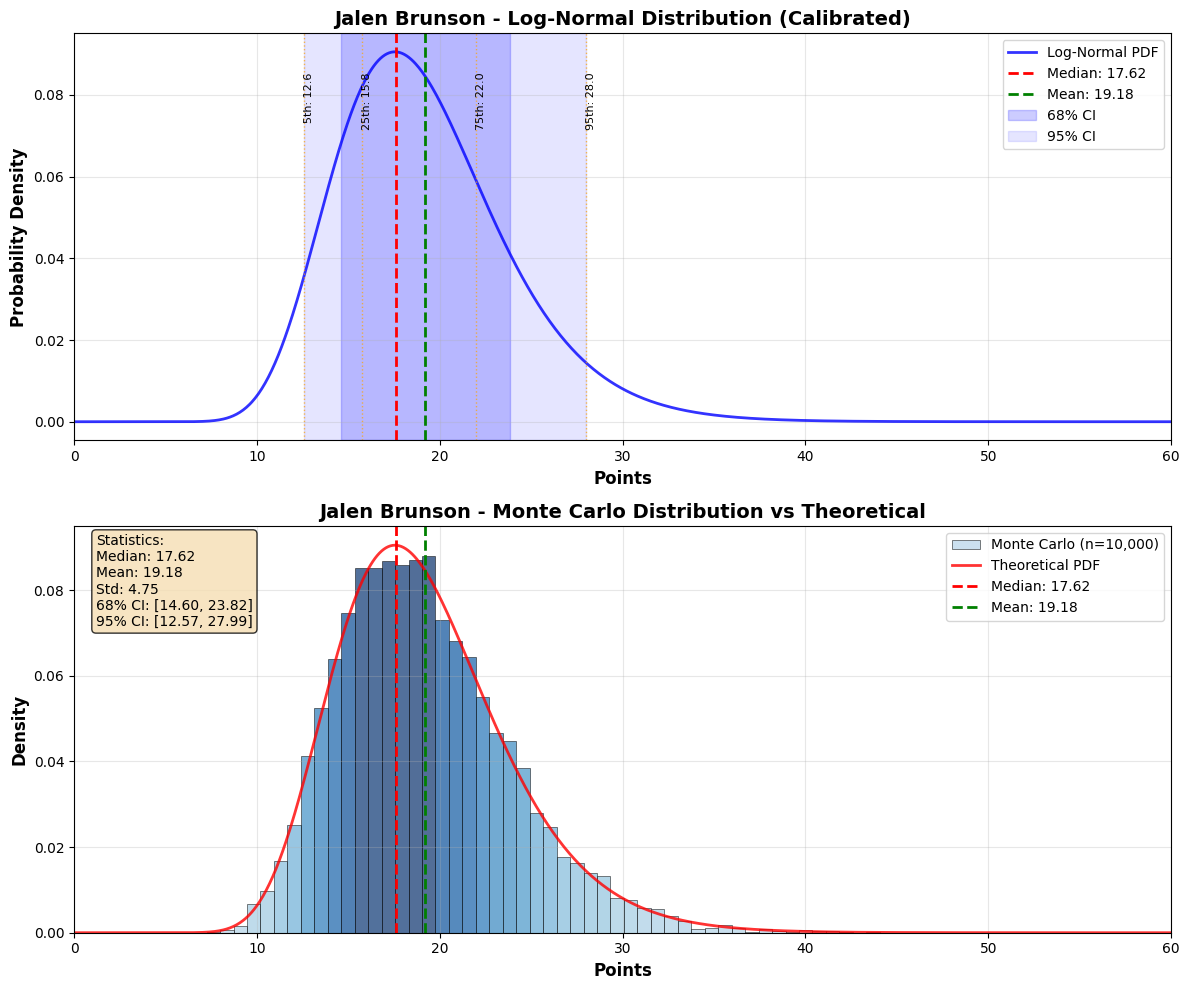

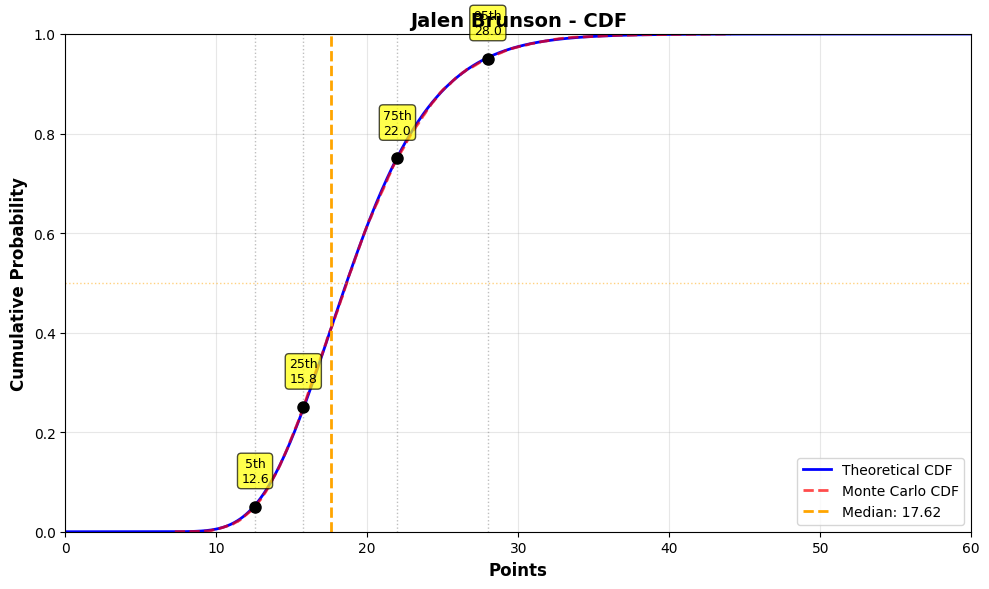

In [23]:
# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ===== TOP PLOT: Theoretical PDF with Statistics =====
ax1 = axes[0]
x = np.linspace(0, max(60, np.percentile(samples, 99)), 1000)
pdf_values = distribution.pdf(x)

# Plot PDF
ax1.plot(x, pdf_values, 'b-', linewidth=2, label='Log-Normal PDF', alpha=0.8)

# Add vertical lines for key statistics
ax1.axvline(median_pred, color='r', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax1.axvline(distribution.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Add confidence intervals
ci_68_low = np.percentile(samples, 16)
ci_68_high = np.percentile(samples, 84)
ci_95_low = np.percentile(samples, 5)
ci_95_high = np.percentile(samples, 95)

ax1.axvspan(ci_68_low, ci_68_high, alpha=0.2, color='blue', label='68% CI')
ax1.axvspan(ci_95_low, ci_95_high, alpha=0.1, color='blue', label='95% CI')

# Add percentiles
percentiles = [5, 25, 75, 95]
percentile_values = [np.percentile(samples, p) for p in percentiles]
percentile_labels = [f'{p}th: {v:.1f}' for p, v in zip(percentiles, percentile_values)]

for p_val, p_label in zip(percentile_values, percentile_labels):
    ax1.axvline(p_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax1.text(p_val, ax1.get_ylim()[1] * 0.9, p_label, rotation=90, 
             verticalalignment='top', fontsize=8)

ax1.set_xlabel('Points', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title(f'{name} - Log-Normal Distribution (Calibrated)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(60, np.percentile(samples, 99)))

# ===== BOTTOM PLOT: Monte Carlo Histogram =====
ax2 = axes[1]

# Create histogram from Monte Carlo samples
n_bins = 50
counts, bins, patches = ax2.hist(samples, bins=n_bins, density=True, alpha=0.7, 
                                  color='steelblue', edgecolor='black', linewidth=0.5,
                                  label=f'Monte Carlo (n={len(samples):,})')

# Overlay theoretical PDF
ax2.plot(x, pdf_values, 'r-', linewidth=2, label='Theoretical PDF', alpha=0.8)

# Add vertical lines for key statistics
ax2.axvline(median_pred, color='red', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax2.axvline(distribution.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Color bars by density (darker = more frequent)
max_count = max(counts)
for count, patch in zip(counts, patches):
    patch.set_facecolor(plt.cm.Blues(0.3 + 0.7 * count / max_count))

# Add text box with statistics
stats_text = f'''Statistics:
Median: {median_pred:.2f}
Mean: {distribution.mean():.2f}
Std: {distribution.std():.2f}
68% CI: [{ci_68_low:.2f}, {ci_68_high:.2f}]
95% CI: [{ci_95_low:.2f}, {ci_95_high:.2f}]'''

ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('Points', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title(f'{name} - Monte Carlo Distribution vs Theoretical', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(60, np.percentile(samples, 99)))

plt.tight_layout()
plt.show()

# ===== Additional: CDF Plot =====
fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

# Plot CDF
cdf_values = distribution.cdf(x)
ax3.plot(x, cdf_values, 'b-', linewidth=2, label='Theoretical CDF')

# Monte Carlo CDF (empirical)
sorted_samples = np.sort(samples)
mc_cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
ax3.plot(sorted_samples, mc_cdf, 'r--', linewidth=2, alpha=0.7, label='Monte Carlo CDF')

# Add median line
ax3.axvline(median_pred, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax3.axhline(0.5, color='orange', linestyle=':', linewidth=1, alpha=0.5)

# Add percentile markers
for p, p_val in zip([5, 25, 75, 95], percentile_values):
    ax3.axvline(p_val, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax3.plot(p_val, p/100, 'ko', markersize=8)
    ax3.text(p_val, p/100 + 0.05, f'{p}th\n{p_val:.1f}', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Points', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title(f'{name} - CDF', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(60, np.percentile(samples, 99)))
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [26]:
# Calculate probabilities using calibrated distribution
line = betting_line
prob_over = 1 - distribution.cdf(line)
prob_under = distribution.cdf(line)

if odds > 0:
    dec_odds = 1 + (odds / 100.0)
else:
    dec_odds = 1 + (100.0 / abs(odds))

# Calculate Expected Value using actual odds
ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)

# Determine recommendation
best_ev = max(ev_over, ev_under)
best_side = "OVER" if ev_over > ev_under else "UNDER"

print(f"\n{'='*60}")
print(f"BETTING ANALYSIS - Line: {line:.1f} | Odds: {odds:+d}")
print(f"{'='*60}")
print(f"Prediction: {median_pred:.2f} points")
print(f"Over {line:.1f}:  {prob_over:.1%} | EV: {ev_over:+.3f}")
print(f"Under {line:.1f}: {prob_under:.1%} | EV: {ev_under:+.3f}")
print(f"\n→ Recommendation: {best_side} {line:.1f} (EV: {best_ev:+.3f})")


BETTING ANALYSIS - Line: 29.5 | Odds: -137
Prediction: 17.62 points
Over 29.5:  3.0% | EV: -0.949
Under 29.5: 97.0% | EV: +0.679

→ Recommendation: UNDER 29.5 (EV: +0.679)


In [29]:
# Filter for Underdog player points
# dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'Underdog') & (dfsData['CATEGORY'] == 'player_points')]
dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'PrizePicks') & (dfsData['CATEGORY'] == 'player_points')]


really_low_volume_lines = dfsPTS[dfsPTS['LINE'].between(4.5, 8.5)]
print(f"Really low volume lines (4.5-7.5): {len(really_low_volume_lines)} bets")

low_volume_lines = dfsPTS[dfsPTS['LINE'].between(9, 15.5)]
print(f"Low volume lines (8.5-15.5): {len(low_volume_lines)} bets")

mid_tier_lines = dfsPTS[dfsPTS['LINE'].between(16, 22.5)]
print(f"Mid-tier lines (15.5-22.5): {len(mid_tier_lines)} bets")

high_volume_lines = dfsPTS[dfsPTS['LINE'].between(23, 35.5)]
print(f"High volume lines (22.5-35.5): {len(high_volume_lines)} bets")

Really low volume lines (4.5-7.5): 36 bets
Low volume lines (8.5-15.5): 94 bets
Mid-tier lines (15.5-22.5): 68 bets
High volume lines (22.5-35.5): 24 bets


In [30]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=really_low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 16 players...
Found 15 valid players
Generated 80 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
27,Isaiah Hartenstein,Isaac Okoro,8.5,6.5,over,over,14.16,13.47,0.953,0.972,0.51,0.51,0.926,0.260,0.666,5.66,6.97,-110,-110,264,3.64,2.3711,237.11,0.2245
29,Keldon Johnson,Jared McCain,8.5,8.5,over,under,12.96,3.41,0.880,0.790,0.49,0.48,0.696,0.235,0.460,4.46,5.09,-102,102,300,4.00,1.7826,178.26,0.1486
56,Luke Kornet,Ryan Kalkbrenner,4.5,8.5,over,over,6.09,9.51,0.754,0.670,0.50,0.49,0.506,0.245,0.261,1.59,1.01,-105,100,290,3.90,0.9717,97.17,0.0838
0,Goga Bitadze,Ajay Mitchell,5.5,8.5,over,over,6.69,10.27,0.688,0.727,0.52,0.48,0.501,0.250,0.251,1.19,1.77,-115,102,278,3.78,0.8919,89.19,0.0802
54,Aaron Wiggins,Jalen Smith,7.5,8.5,over,under,10.36,6.07,0.773,0.576,0.55,0.49,0.446,0.270,0.176,2.86,2.43,-128,100,256,3.56,0.5866,58.66,0.0573
46,Luguentz Dort,Jose Alvarado,7.5,8.5,under,under,4.39,7.26,0.643,0.474,0.46,0.50,0.305,0.230,0.075,3.11,1.24,110,-103,314,4.14,0.2627,26.27,0.0209
37,Julian Champagnie,Vít Krejčí,8.0,7.5,under,under,5.34,6.89,0.597,0.420,0.56,0.50,0.251,0.280,-0.029,2.66,0.61,-137,-106,236,3.36,-0.1566,-15.66,0.0000


In [31]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 46 players...
Found 45 valid players
Generated 899 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
366,Dylan Harper,Deandre Ayton,9.5,14.5,over,under,14.95,7.84,0.915,0.872,0.54,0.51,0.798,0.275,0.522,5.45,6.66,-122,-108,250,3.50,1.7913,179.13,0.1791
802,Saddiq Bey,Quinten Post,15.5,9.5,under,under,8.48,2.89,0.857,0.848,0.51,0.51,0.726,0.260,0.466,7.02,6.61,-108,-110,268,3.68,1.6734,167.34,0.1561
816,Matas Buzelis,Marcus Smart,13.5,10.5,under,under,6.34,2.92,0.830,0.879,0.54,0.53,0.730,0.286,0.443,7.16,7.58,-122,-119,235,3.35,1.4441,144.41,0.1536
879,Dennis Schröder,Mark Williams,10.5,11.5,over,under,14.49,7.38,0.828,0.780,0.54,0.49,0.646,0.265,0.381,3.99,4.12,-122,100,264,3.64,1.3501,135.01,0.1278
830,Naz Reid,Rui Hachimura,14.5,12.5,under,under,7.39,5.06,0.800,0.826,0.55,0.54,0.661,0.297,0.364,7.11,7.44,-127,-122,225,3.25,1.1469,114.69,0.1274
319,Harrison Barnes,Jeremiah Fears,10.5,15.5,under,under,5.33,9.73,0.741,0.783,0.51,0.54,0.580,0.275,0.304,5.17,5.77,-110,-123,246,3.46,1.0059,100.59,0.1022
48,Mikal Bridges,Jarrett Allen,14.5,12.5,under,over,10.31,14.76,0.671,0.743,0.49,0.52,0.499,0.255,0.244,4.19,2.26,100,-114,275,3.75,0.8715,87.15,0.0792
195,Tristan da Silva,Stephon Castle,9.0,15.0,under,over,4.31,17.35,0.766,0.750,0.56,0.56,0.575,0.314,0.261,4.69,2.35,-137,-137,199,2.99,0.7178,71.78,0.0902
90,OG Anunoby,Dyson Daniels,14.5,12.5,over,under,16.53,8.34,0.661,0.717,0.53,0.56,0.474,0.297,0.177,2.03,4.16,-120,-137,217,3.17,0.5029,50.29,0.0579
633,VJ Edgecombe,Nikola Vučević,11.5,15.5,over,under,12.94,11.61,0.670,0.655,0.54,0.54,0.439,0.292,0.148,1.44,3.89,-124,-122,229,3.29,0.4456,44.56,0.0486


In [32]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=mid_tier_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 34 players...
Found 34 valid players
Generated 517 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
73,Desmond Bane,Onyeka Okongwu,20.5,17.5,under,under,8.43,5.30,0.955,0.930,0.50,0.53,0.888,0.265,0.623,12.07,12.20,-103,-120,261,3.61,2.2074,220.74,0.2114
199,Chet Holmgren,CJ McCollum,16.5,20.5,over,under,20.56,11.44,0.817,0.862,0.49,0.53,0.704,0.260,0.445,4.06,9.06,100,-117,271,3.71,1.6133,161.33,0.1488
24,Paolo Banchero,Devin Booker,22.5,21.5,under,under,16.05,15.65,0.843,0.800,0.54,0.50,0.675,0.270,0.405,6.45,5.85,-122,-105,255,3.55,1.3953,139.53,0.1368
56,Karl-Anthony Towns,Dillon Brooks,21.5,18.5,under,over,15.47,22.46,0.796,0.800,0.51,0.50,0.637,0.255,0.382,6.03,3.96,-111,-106,269,3.69,1.3516,135.16,0.1256
309,Brandon Miller,Shaedon Sharpe,22.5,21.5,under,under,15.56,15.40,0.822,0.811,0.54,0.53,0.667,0.286,0.380,6.94,6.10,-124,-119,232,3.32,1.2131,121.31,0.1307
342,Kon Knueppel,Zach LaVine,19.5,21.5,under,under,12.03,14.50,0.831,0.802,0.56,0.53,0.666,0.297,0.370,7.47,7.00,-137,-118,220,3.20,1.1326,113.26,0.1287
429,Kevin Porter Jr.,Jerami Grant,21.5,20.5,under,under,16.67,15.45,0.732,0.772,0.51,0.54,0.565,0.275,0.290,4.83,5.05,-108,-122,250,3.50,0.9778,97.78,0.0978
109,Jalen Suggs,Derik Queen,17.5,16.5,under,under,12.10,11.76,0.739,0.756,0.53,0.53,0.559,0.281,0.278,5.40,4.74,-120,-118,239,3.39,0.8939,89.39,0.0935
485,Jordan Poole,LeBron James,16.5,20.5,over,under,18.13,16.58,0.678,0.665,0.50,0.52,0.451,0.260,0.191,1.63,3.92,-103,-113,272,3.72,0.6780,67.80,0.0623
357,Darius Garland,Josh Giddey,17.5,20.5,under,under,13.62,16.55,0.655,0.656,0.51,0.50,0.430,0.255,0.175,3.88,3.95,-111,-105,271,3.71,0.5938,59.38,0.0548


In [12]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=high_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 14 players...
Found 14 valid players
Generated 86 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
26,Coby White,Joel Embiid,22.5,23.5,over,under,27.43,15.26,0.880,0.913,0.48,0.51,0.804,0.245,0.559,4.93,8.24,104,-110,289,3.89,2.1258,212.58,0.1839
47,Donovan Mitchell,Michael Porter Jr.,29.5,23.5,under,under,21.71,15.25,0.837,0.842,0.50,0.48,0.704,0.240,0.464,7.79,8.25,-104,105,302,4.02,1.8312,183.12,0.1516
13,Jalen Johnson,Miles Bridges,24.5,22.5,under,under,16.95,15.91,0.882,0.852,0.53,0.52,0.751,0.276,0.476,7.55,6.59,-118,-112,250,3.50,1.6290,162.90,0.1629
80,Anthony Davis,Shai Gilgeous-Alexander,22.5,31.5,under,under,16.28,23.27,0.805,0.838,0.51,0.53,0.674,0.270,0.404,6.22,8.23,-110,-121,249,3.49,1.3526,135.26,0.1358
10,Cade Cunningham,Jalen Brunson,26.5,28.5,under,under,20.68,23.50,0.781,0.717,0.51,0.52,0.560,0.265,0.295,5.82,5.00,-111,-114,257,3.57,0.9992,99.92,0.0972
69,Lauri Markkanen,Stephen Curry,25.5,24.5,under,over,20.75,26.56,0.704,0.684,0.51,0.50,0.481,0.255,0.226,4.75,2.06,-110,-105,273,3.73,0.7957,79.57,0.0729
57,Pascal Siakam,Julius Randle,23.5,23.5,under,under,21.68,21.05,0.523,0.572,0.50,0.48,0.299,0.240,0.059,1.82,2.45,-105,105,300,4.00,0.1978,19.78,0.0165


## For low line players

In [13]:
players = really_low_volume_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_fg3a': round(result.get('predicted_fg3a'),2),
        'predicted_fta': round(result.get('predicted_fta'),2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

,player,predicted_minutes,predicted_fga,predicted_fg3a,predicted_fta,predicted_points
0,Caris LeVert,19.44,8.71,5.34,3.43,15.42
1,Luke Kennard,21.07,7.87,5.45,1.90,12.08
2,Ryan Kalkbrenner,25.07,5.68,0.54,2.50,8.83
3,Patrick Williams,20.94,8.24,4.23,2.32,11.92
4,Sion James,22.56,6.59,5.07,1.54,9.24
5,Zach Collins,23.42,8.63,3.48,3.47,12.73
6,Liam McNeeley,18.36,5.86,3.06,1.67,6.16
7,Isaac Okoro,26.95,6.82,3.64,2.26,8.51
8,T.J. McConnell,16.30,8.96,2.15,1.75,12.53
9,Dominick Barlow,26.69,5.75,1.70,2.00,7.10


In [14]:
players = low_volume_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_fg3a': round(result.get('predicted_fg3a'),2),
        'predicted_fta': round(result.get('predicted_fta'),2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

,player,predicted_minutes,predicted_fga,predicted_fg3a,predicted_fta,predicted_points
0,Tobias Harris,30.63,13.19,5.90,4.45,18.60
1,Dyson Daniels,27.00,7.78,1.15,1.73,7.67
2,Ausar Thompson,27.53,8.85,0.51,3.79,13.66
3,Duncan Robinson,29.99,9.62,7.85,1.91,13.40
4,Zaccharie Risacher,25.63,11.27,6.59,2.03,16.17
5,Caris LeVert,19.44,8.71,5.34,3.43,15.42
6,Matas Buzelis,29.10,9.48,3.66,2.78,11.02
7,KJ Simpson,30.29,10.76,3.66,1.78,10.60
8,Tre Jones,26.66,8.78,2.10,4.25,13.26
9,Ryan Kalkbrenner,25.07,5.68,0.54,2.50,8.83


## For mid line players

In [15]:
players = mid_tier_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_fg3a': round(result.get('predicted_fg3a'),2),
        'predicted_fta': round(result.get('predicted_fta'),2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

,player,predicted_minutes,predicted_fga,predicted_fg3a,predicted_fta,predicted_points
0,Nickeil Alexander-Walker,30.44,9.24,4.12,2.42,8.57
1,Jalen Duren,28.20,9.83,0.45,4.61,16.91
2,Onyeka Okongwu,31.02,8.78,3.40,1.77,8.31
3,Coby White,31.50,18.68,8.03,7.69,27.43
4,Miles Bridges,31.45,13.38,5.98,5.18,15.91
5,Brandon Miller,31.17,15.19,7.89,3.85,17.56
6,Josh Giddey,27.37,11.90,5.05,6.48,19.73
7,Kon Knueppel,31.06,11.05,5.06,2.37,10.27
8,Evan Mobley,29.72,13.01,4.79,3.84,17.75
9,Darius Garland,27.89,11.40,4.87,3.18,12.74


## High Value Lines

In [16]:
players = high_volume_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_fg3a': round(result.get('predicted_fg3a'),2),
        'predicted_fta': round(result.get('predicted_fta'),2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

,player,predicted_minutes,predicted_fga,predicted_fg3a,predicted_fta,predicted_points
0,Cade Cunningham,32.81,15.48,3.36,6.17,20.68
1,Jalen Johnson,32.95,12.03,4.35,5.59,16.95
2,Coby White,31.50,18.68,8.03,7.69,27.43
3,Miles Bridges,31.45,13.38,5.98,5.18,15.91
4,Donovan Mitchell,32.31,15.87,7.64,5.63,21.71
5,Pascal Siakam,31.57,15.22,5.71,5.19,21.68
6,Joel Embiid,25.79,10.22,4.84,5.20,15.26
7,Lauri Markkanen,33.21,16.20,6.36,4.59,20.75
8,Anthony Davis,28.43,13.53,2.39,4.38,16.28
9,Stephen Curry,33.38,19.50,11.59,4.48,26.56
